In [1]:
pip install transformers datasets torch scikit-learn pandas langdetect

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 14.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.4/491.4 kB 27.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 68.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 63.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 38.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 98.2 MB/s eta 0:00:00


In [2]:
pip install datasets

In [3]:
import torch
from transformers import XLMRobertaTokenizer, XLMRobertaForSequenceClassification
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from transformers import Trainer, TrainingArguments
import pandas as pd
from sklearn.model_selection import train_test_split
from transformers import BertTokenizer
import re

In [8]:
from transformers import pipeline, BertForSequenceClassification, BertTokenizer

In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [11]:
# Load models
classification_model = BertForSequenceClassification.from_pretrained("my_model").to(device)
classification_tokenizer = BertTokenizer.from_pretrained("my_tokenizer")

In [14]:
# Label Maps
label_map = {
    "Billing and Payments": 0,
    "Customer Service": 1,
    "General Inquiry": 2,
    "Human Resources": 3,
    "IT Support": 4,
    "Product Support": 5,
    "Returns and Exchanges": 6,
    "Sales and Pre-Sales": 7,
    "Service Outages and Maintenance": 8,
    "Technical Support": 9
}
reverse_label_map = {v: k for k, v in label_map.items()}

In [15]:
def classify_email(subject, body):
    text = subject + " " + body
    inputs = classification_tokenizer(text, return_tensors="pt", padding="max_length", truncation=True, max_length=128)
    inputs = {k: v.to(device) for k, v in inputs.items()}
    with torch.no_grad():
        outputs = classification_model(**inputs)
    predicted_class = torch.argmax(outputs.logits, axis=-1).item()
    return reverse_label_map[predicted_class]

In [16]:
from sklearn.metrics import classification_report

# Load test data with true labels
test_df = pd.read_csv("SupportDataset.csv")  # make sure you have this
test_df.dropna(subset=["subject", "body", "answer"], inplace=True)

test_df["text"] = test_df["subject"] + " " + test_df["body"]

label_map = {label: idx for idx, label in enumerate(sorted(test_df['queue'].unique()))}

test_df['queue'] = test_df['queue'].map(label_map)

# Get predictions from model
predictions = []
true_labels = []

for _, row in test_df.iterrows():
    pred = classify_email(row["subject"], row["body"])
    predictions.append(label_map[pred])
    true_labels.append(row["queue"])

# Generate metrics
print(classification_report(true_labels, predictions, target_names=label_map.keys()))

                                 precision    recall  f1-score   support

           Billing and Payments       0.87      0.74      0.80      1193
               Customer Service       0.35      0.42      0.38      1710
                General Inquiry       0.00      0.00      0.00       148
                Human Resources       0.88      0.27      0.42       183
                     IT Support       0.75      0.03      0.06      1274
                Product Support       0.41      0.40      0.41      2034
          Returns and Exchanges       0.61      0.11      0.18       530
            Sales and Pre-Sales       0.50      0.00      0.01       282
Service Outages and Maintenance       0.75      0.49      0.60       415
              Technical Support       0.47      0.81      0.59      3119

                       accuracy                           0.49     10888
                      macro avg       0.56      0.33      0.34     10888
                   weighted avg       0.53      0

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [18]:
# Label Maps
label_map = {
    "Billing and Payments": 0,
    "Customer Service": 1,
    "General Inquiry": 2,
    "Human Resources": 3,
    "IT Support": 4,
    "Product Support": 5,
    "Returns and Exchanges": 6,
    "Sales and Pre-Sales": 7,
    "Service Outages and Maintenance": 8,
    "Technical Support": 9
}

In [20]:
import torch
from transformers import BertTokenizer, BertForSequenceClassification
import pandas as pd
import json
from sklearn.metrics import classification_report

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load trained model and tokenizer
from transformers import BertForSequenceClassification, BertTokenizer
classification_model = BertForSequenceClassification.from_pretrained("my_model").to(device)
classification_tokenizer = BertTokenizer.from_pretrained("my_tokenizer")

# Correct label mapping (must match what was used during training)
label_map = {
    "Billing and Payments": 0,
    "Customer Service": 1,
    "General Inquiry": 2,
    "Human Resources": 3,
    "IT Support": 4,
    "Product Support": 5,
    "Returns and Exchanges": 6,
    "Sales and Pre-Sales": 7,
    "Service Outages and Maintenance": 8,
    "Technical Support": 9
}
reverse_label_map = {v: k for k, v in label_map.items()}

# Classification function
def classify_email(subject, body):
    text = subject + " " + body
    inputs = classification_tokenizer(text, return_tensors="pt", padding="max_length", truncation=True, max_length=128)
    inputs = {k: v.to(device) for k, v in inputs.items()}
    with torch.no_grad():
        outputs = classification_model(**inputs)
    predicted_class = torch.argmax(outputs.logits, axis=-1).item()
    return reverse_label_map[predicted_class]

# Load test data
test_df = pd.read_csv("SupportDataset.csv")
test_df.dropna(subset=["subject", "body", "queue"], inplace=True)

# Map true labels using the same label_map
test_df['label_id'] = test_df['queue'].map(label_map)

# Generate predictions
predictions = []
true_labels = []

for _, row in test_df.iterrows():
    pred_label = classify_email(row["subject"], row["body"])  # e.g., "Billing and Payments"
    predictions.append(label_map[pred_label])  # Convert label string to ID
    true_labels.append(row["label_id"])

# Evaluate
print(classification_report(true_labels, predictions, target_names=label_map.keys()))

                                 precision    recall  f1-score   support

           Billing and Payments       0.87      0.74      0.80      1194
               Customer Service       0.35      0.42      0.38      1710
                General Inquiry       0.00      0.00      0.00       148
                Human Resources       0.88      0.27      0.42       183
                     IT Support       0.75      0.03      0.06      1274
                Product Support       0.41      0.40      0.41      2035
          Returns and Exchanges       0.61      0.11      0.18       530
            Sales and Pre-Sales       0.50      0.00      0.01       282
Service Outages and Maintenance       0.75      0.49      0.60       415
              Technical Support       0.47      0.81      0.59      3119

                       accuracy                           0.49     10890
                      macro avg       0.56      0.33      0.34     10890
                   weighted avg       0.53      0

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [21]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(true_labels, predictions)
print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.4860


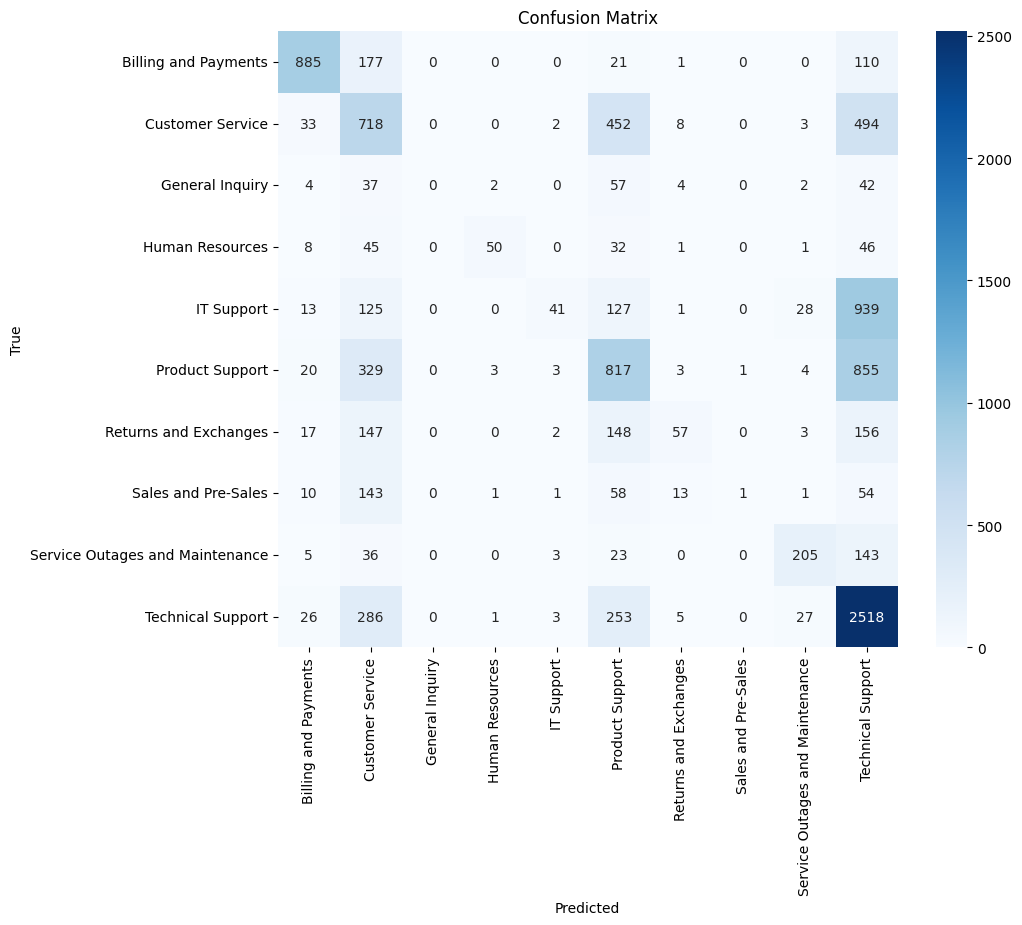

In [22]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(true_labels, predictions)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=label_map.keys(), yticklabels=label_map.keys(), cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

In [25]:
print(cm)

[[ 885  177    0    0    0   21    1    0    0  110]
 [  33  718    0    0    2  452    8    0    3  494]
 [   4   37    0    2    0   57    4    0    2   42]
 [   8   45    0   50    0   32    1    0    1   46]
 [  13  125    0    0   41  127    1    0   28  939]
 [  20  329    0    3    3  817    3    1    4  855]
 [  17  147    0    0    2  148   57    0    3  156]
 [  10  143    0    1    1   58   13    1    1   54]
 [   5   36    0    0    3   23    0    0  205  143]
 [  26  286    0    1    3  253    5    0   27 2518]]


Label Distribution:
 Billing and Payments               1194
Customer Service                   1710
General Inquiry                     148
Human Resources                     183
IT Support                         1274
Product Support                    2035
Returns and Exchanges               530
Sales and Pre-Sales                 282
Service Outages and Maintenance     415
Technical Support                  3119
Name: count, dtype: int64


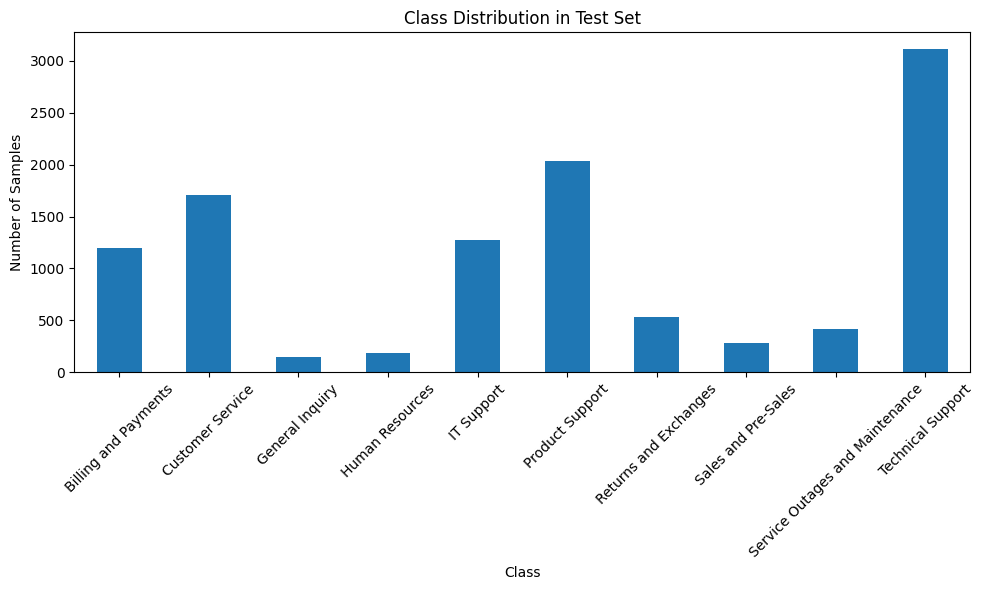

In [24]:
import pandas as pd
import matplotlib.pyplot as plt

# Count the number of instances per class
label_counts = test_df['queue'].value_counts().sort_index()

# Map back to class names for readability
class_names = [k for k, v in sorted(label_map.items(), key=lambda x: x[1])]
label_counts.index = class_names

# Display counts
print("Label Distribution:\n", label_counts)

# Plot the class distribution
plt.figure(figsize=(10, 6))
label_counts.plot(kind='bar')
plt.title("Class Distribution in Test Set")
plt.xlabel("Class")
plt.ylabel("Number of Samples")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [23]:
from sklearn.metrics import f1_score

macro_f1 = f1_score(true_labels, predictions, average='macro')
weighted_f1 = f1_score(true_labels, predictions, average='weighted')

print(f"Macro F1-score: {macro_f1:.4f}")
print(f"Weighted F1-score: {weighted_f1:.4f}")

Macro F1-score: 0.3445
Weighted F1-score: 0.4398


In [ ]:
import pandas as pd

# Load the dataset
df = pd.read_csv('/content/SupportDataset.csv')

# Check the first few rows
print(df.head())
print(df.columns)

                                             subject  \
0  Problema crítico del servidor requiere atenció...   
1     Anfrage zur Verfügbarkeit des Dell XPS 13 9310   
2  Erro na Autocompletação de Código do IntelliJ ...   
3            Urgent Assistance Required: AWS Service   
4                Problème d'affichage de MacBook Air   

                                                body  \
0  Es necesaria una investigación inmediata sobre...   
1  Sehr geehrter Kundenservice,\n\nich hoffe, die...   
2  Prezado Suporte ao Cliente <name>,\n\nEstou es...   
3  Dear IT Services Support Team, \n\nI am reachi...   
4  Cher équipe de support du magasin en ligne Tec...   

                                              answer      type  \
0  Estamos investigando urgentemente el problema ...  Incident   
1  Sehr geehrter <name>,\n\nvielen Dank, dass Sie...   Request   
2  Prezado <name>,\n\nObrigado por entrar em cont...  Incident   
3  Dear <name>,\n\nThank you for reaching out reg...   Request

In [ ]:
df = df.drop(columns=['tag_3', 'tag_4', 'tag_5', 'tag_6', 'tag_7', 'tag_8'])

df = df.dropna(subset=['subject', 'body', 'answer'])

df['text'] = df['subject'] + " " + df['body']



<ipython-input-6-a84c381c9567>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['text'] = df['subject'] + " " + df['body']


In [ ]:
print(df['queue'].unique())


['Technical Support' 'Customer Service' 'IT Support' 'Product Support'
 'Billing and Payments' 'Service Outages and Maintenance'
 'General Inquiry' 'Returns and Exchanges' 'Sales and Pre-Sales'
 'Human Resources']


In [ ]:
unique_labels = sorted(df['queue'].unique())
label_map = {label: idx for idx, label in enumerate(unique_labels)}

In [ ]:
label_map = {label: idx for idx, label in enumerate(sorted(df['queue'].unique()))}

df['queue'] = df['queue'].map(label_map)

print("Label Mapping:", label_map)
print(df[['queue']].head())


Label Mapping: {'Billing and Payments': 0, 'Customer Service': 1, 'General Inquiry': 2, 'Human Resources': 3, 'IT Support': 4, 'Product Support': 5, 'Returns and Exchanges': 6, 'Sales and Pre-Sales': 7, 'Service Outages and Maintenance': 8, 'Technical Support': 9}
   queue
0      9
1      1
2      9
3      4
4      5


In [ ]:
from transformers import BertTokenizer, BertForSequenceClassification, Trainer, TrainingArguments
from datasets import Dataset, DatasetDict
import torch
from sklearn.model_selection import train_test_split

tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
#tokenizer = BertTokenizer.from_pretrained('yiyanghkust/finbert')

def tokenize_function(examples):
    return tokenizer(examples['text'], padding="max_length", truncation=True, max_length=128)

# Assuming your original DataFrame is df
# Convert DataFrame to Hugging Face Dataset (this is required to use `map`)
dataset = Dataset.from_pandas(df)

# Split dataset using scikit-learn (train_test_split)
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)
if '__index_level_0__' in train_df.columns:
    train_df = train_df.drop(columns=['__index_level_0__'])

if '__index_level_0__' in test_df.columns:
    test_df = test_df.drop(columns=['__index_level_0__'])

# Convert the DataFrames back to Hugging Face Datasets
train_dataset = Dataset.from_pandas(train_df)
test_dataset = Dataset.from_pandas(test_df)

# Tokenize the train and test datasets
train_dataset = train_dataset.map(tokenize_function, batched=True)
test_dataset = test_dataset.map(tokenize_function, batched=True)

num_labels = len(label_map)

# Map string labels to integers
label_map = {label: idx for idx, label in enumerate(unique_labels)}

train_dataset = train_dataset.map(lambda x: {'labels': label_map[x['queue']]})
test_dataset = test_dataset.map(lambda x: {'labels': label_map[x['queue']]})


# Ensure the format is correct (torch tensors)
train_dataset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'labels'])
test_dataset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'labels'])

# Load the pre-trained BERT model for sequence classification
model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=num_labels)

# Define the Training Arguments
training_args = TrainingArguments(
    output_dir='./results',
    evaluation_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=3,
    weight_decay=0.01,
    logging_dir='./logs',
)

# Define the Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    tokenizer=tokenizer,  # Tokenizer to handle batching correctly
)

# Start the training process
trainer.train()

# After training, evaluate the model
results = trainer.evaluate()

# Print results
print(results)

Map:   0%|          | 0/8710 [00:00<?, ? examples/s]

Map:   0%|          | 0/2178 [00:00<?, ? examples/s]

Map:   0%|          | 0/8710 [00:00<?, ? examples/s]

Map:   0%|          | 0/2178 [00:00<?, ? examples/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.11/dist-packages/transformers/training_args.py:1575: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(
<ipython-input-7-621989787bc9>:64: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss
1,1.635600,1.612886
2,1.494300,1.551557
3,1.309800,1.543035


{'eval_loss': 1.5430349111557007, 'eval_runtime': 14.985, 'eval_samples_per_second': 145.346, 'eval_steps_per_second': 18.218, 'epoch': 3.0}


In [ ]:
from transformers import BertTokenizer, BertForSequenceClassification, Trainer, TrainingArguments
from datasets import Dataset
import torch
from sklearn.model_selection import train_test_split

# Tokenizer for BERT model
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

# Tokenization function
def tokenize_function(examples):
    return tokenizer(examples['text'], padding="max_length", truncation=True, max_length=128)

# Convert DataFrame to Hugging Face Dataset
dataset = Dataset.from_pandas(df)

# Split dataset using scikit-learn
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

# Remove any unwanted index column
train_df = train_df.drop(columns=['__index_level_0__'], errors="ignore")
test_df = test_df.drop(columns=['__index_level_0__'], errors="ignore")

# Convert DataFrames to Hugging Face Dataset format
train_dataset = Dataset.from_pandas(train_df)
test_dataset = Dataset.from_pandas(test_df)

# Tokenize datasets
train_dataset = train_dataset.map(tokenize_function, batched=True)
test_dataset = test_dataset.map(tokenize_function, batched=True)

# Ensure label mapping is consistent
num_labels = len(label_map)  # Fixes issue with incorrect label count

# Rename 'queue' to 'labels' for classification
train_dataset = train_dataset.rename_column("queue", "labels")
test_dataset = test_dataset.rename_column("queue", "labels")

# Define required columns for Hugging Face Trainer
required_columns = ["input_ids", "attention_mask", "labels"]

# Identify extra columns
extra_columns = [col for col in train_dataset.column_names if col not in required_columns]

# Remove extra columns dynamically
train_dataset = train_dataset.remove_columns(extra_columns)
test_dataset = test_dataset.remove_columns(extra_columns)

print("Remaining columns in train dataset:", train_dataset.column_names)

# Convert datasets into correct tensor format
train_dataset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'labels'])
test_dataset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'labels'])

# Load the pre-trained BERT model for classification
model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=num_labels)

# Define Training Arguments
training_args = TrainingArguments(
    output_dir='./results',
    evaluation_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=2,  # Reduce if overfitting
    weight_decay=0.01,
    logging_dir='./logs',
)

# Define the Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    tokenizer=tokenizer,
)

# Start Training
trainer.train()

# Evaluate Model
results = trainer.evaluate()

# Print Evaluation Results
print(results)


Map:   0%|          | 0/8710 [00:00<?, ? examples/s]

Map:   0%|          | 0/2178 [00:00<?, ? examples/s]

Remaining columns in train dataset: ['labels', 'input_ids', 'attention_mask']


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.11/dist-packages/transformers/training_args.py:1575: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(
<ipython-input-8-d6a31d063abc>:70: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
wandb: WARNING The `run_name` is currently set to the same value as `TrainingArguments.output_dir`. If this was not intended, please specify a different run name by setting the `TrainingArguments.run_name` parameter.
wandb: Using wandb-core as the SDK backend.  Please refer to https://wand

Epoch,Training Loss,Validation Loss
1,1.651400,1.625282
2,1.510000,1.565760


{'eval_loss': 1.5657603740692139, 'eval_runtime': 14.7803, 'eval_samples_per_second': 147.359, 'eval_steps_per_second': 18.471, 'epoch': 2.0}


In [ ]:
# Save the trained model
model.save_pretrained("./my_model")

# Save the tokenizer
tokenizer.save_pretrained("./my_tokenizer")

('./my_tokenizer/tokenizer_config.json',
 './my_tokenizer/special_tokens_map.json',
 './my_tokenizer/vocab.txt',
 './my_tokenizer/added_tokens.json')

In [ ]:
training_args.save("./training_args")

AttributeError: 'TrainingArguments' object has no attribute 'save'

In [ ]:
# Evaluate on the test set
test_results = trainer.evaluate(test_dataset)
print(test_results)

{'eval_loss': 1.5430349111557007, 'eval_runtime': 14.0797, 'eval_samples_per_second': 154.69, 'eval_steps_per_second': 19.39, 'epoch': 3.0}


In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e

In [ ]:
from transformers import BertTokenizer, BertForSequenceClassification

# Load the saved model and tokenizer
offline_model = BertForSequenceClassification.from_pretrained("./my_model")
offline_tokenizer = BertTokenizer.from_pretrained("./my_tokenizer")

print("Model loaded successfully!")


Model loaded successfully!


In [ ]:
import torch

def predict(text):
    # Tokenize input text
    inputs = offline_tokenizer(text, return_tensors="pt", padding="max_length", truncation=True, max_length=128)

    # Run inference
    with torch.no_grad():
        outputs = offline_model(**inputs)

    # Get predicted class
    predicted_class = torch.argmax(outputs.logits, axis=-1).item()

    return predicted_class

# Example usage
text = "My payment is not processing. What should I do?"
predicted_label = predict(text)
print(f"Predicted Class: {predicted_label}")

# Reverse the mapping
reverse_label_map = {v: k for k, v in label_map.items()}  # Flip key-value pairs

# Get predicted class name
predicted_class = reverse_label_map[0]  # Using 8 from tensor([8])
print("Predicted Category:", predicted_class)

Predicted Class: 0
Predicted Category: Billing and Payments
